In [7]:
import pandas as pd
import numpy as np
import scipy
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [8]:
# Load dataset
data = pd.read_csv("HousePricingData.csv")
data

,Id,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,Fireplaces,GarageCars,PavedDrive,SaleCondition,SalePrice
0,1,8450,7,5,2003,856,856,854,1710,1,0,2,1,3,1,0,2,Y,Normal,208500
1,2,9600,6,8,1976,1262,1262,0,1262,0,1,2,0,3,1,1,2,Y,Normal,181500
2,3,11250,7,5,2001,920,920,866,1786,1,0,2,1,3,1,1,2,Y,Normal,223500
3,4,9550,7,5,1915,756,961,756,1717,1,0,1,0,3,1,1,3,Y,Abnorml,140000
4,5,14260,8,5,2000,1145,1145,1053,2198,1,0,2,1,4,1,1,3,Y,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,7917,6,5,1999,953,953,694,1647,0,0,2,1,3,1,1,2,Y,Normal,175000
1456,1457,13175,6,6,1978,1542,2073,0,2073,1,0,2,0,3,1,2,2,Y,Normal,210000
1457,1458,9042,7,9,1941,1152,1188,1152,2340,0,0,2,0,4,1,2,1,Y,Normal,266500
1458,1459,9717,5,6,1950,1078,1078,0,1078,1,0,1,0,2,1,0,1,Y,Normal,142125


In [9]:


# Q1: Regression between GrLivArea and SalePrice
X1 = data['GrLivArea']
y1 = data['SalePrice']
X1_with_const = sm.add_constant(X1)
model1 = sm.OLS(y1, X1_with_const).fit()
model1.summary()

#print(model1.summary())


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     1471.
Date:                Sun, 20 Oct 2024   Prob (F-statistic):          4.52e-223
Time:                        16:32:42   Log-Likelihood:                -18035.
No. Observations:                1460   AIC:                         3.607e+04
Df Residuals:                    1458   BIC:                         3.608e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.857e+04   4480.755      4.144      0.000    9779.612    2.74e+04
GrLivArea    107.1304      2.794     38.348      0.000     101.650     112.610
==============================================================================
Omnibus:                      261.166   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3432.287
Skew:                           0.410   Prob(JB):                         0.00
Kurtosis:                      10.467   Cond. No.                     4.90e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [10]:
model1.pvalues

const         3.606554e-05
GrLivArea    4.518034e-223
dtype: float64

### interpretation
R-squared: 0.502
Since this is above 0.3, it indicates a good relationship between the two variables GrLivArea and SalePrice.
For every additional square foot of above-ground living area, the sale price increases by approximately $107.13.

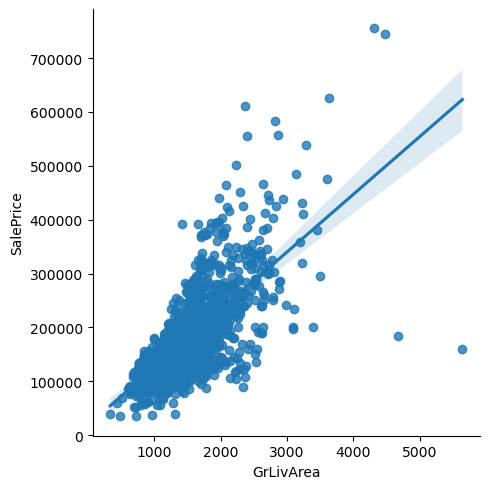

In [12]:
 #Scatter plot with regression line
sns.lmplot(x='GrLivArea', y='SalePrice', data=data)

In [13]:
#2
X2 = data['TotalBsmtSF']
y2 = data['LotArea']
X2_with_const = sm.add_constant(X2)
model2 = sm.OLS(y2, X2_with_const).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                LotArea   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     106.4
Date:                Sun, 20 Oct 2024   Prob (F-statistic):           3.91e-24
Time:                        16:32:43   Log-Likelihood:                -15464.
No. Observations:                1460   AIC:                         3.093e+04
Df Residuals:                    1458   BIC:                         3.094e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4241.6386    658.492      6.441      0.000    2949.946    5533.331
TotalBsmtSF     5.9344      0.575     10.317      0.000       4.806       7.063
==============================================================================
Omnibus:                     2613.787   Durbin-Watson:                   2.032
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2702216.991
Skew:                          12.411   Prob(JB):                         0.00
Kurtosis:                     212.294   Cond. No.                     2.99e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.99e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [14]:
model2.pvalues

const          1.603215e-10
TotalBsmtSF    3.911258e-24
dtype: float64

### interpretation
R-squared: 0.068
Since this is below 0.3, it indicates a weak relationship between the two variables TotalBsmtSF and LotArea.
The lot size grows by 5.93 square feet for every square foot of basement space added.

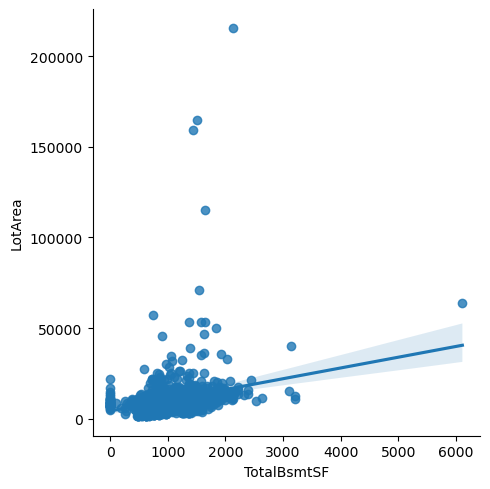

In [16]:
# Scatter plot with regression line
sns.lmplot(x='TotalBsmtSF', y='LotArea', data=data)

In [27]:
#3
corr_1 = data['GrLivArea'].corr(data['SalePrice'])
corr_2 = data['TotalBsmtSF'].corr(data['LotArea'])

print(f"Correlation between GrLivArea and SalePrice: {corr_1}")
print(f"Correlation between TotalBsmtSF and LotArea: {corr_2}")


Correlation between GrLivArea and SalePrice: 0.7086244776126522
Correlation between TotalBsmtSF and LotArea: 0.2608331345451576


### Indication
GrLivArea and SalePrice: Correlation = 0.709 which is closer to 1 indicating a strong positive correlation. As living area increases, sale price tends to increase.
TotalBsmtSF and LotArea: Correlation = 0.261 which is not close to1 indicating a weak positive correlation, supporting the conclusion that basement area alone does not strongly determine lot size.

In [64]:
#4
one_hot = pd.get_dummies(data, columns = ['PavedDrive', 'SaleCondition'], dtype=int)
X4 = one_hot.drop(['SalePrice'], axis=1)
Y4 = one_hot['SalePrice']
X_four_const = sm.add_constant(X4)
model4 = sm.OLS(Y4,X_four_const).fit()
model4.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     244.4
Date:                Sun, 20 Oct 2024   Prob (F-statistic):               0.00
Time:                        17:27:03   Log-Likelihood:                -17356.
No. Observations:                1460   AIC:                         3.476e+04
Df Residuals:                    1435   BIC:                         3.489e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -4.932e+05    7.3e+04     -6.757      0.000   -6.36e+05    -3.5e+05
Id                       -2.0287      2.221     -0.913      0.361      -6.386       2.328
LotArea                   0.4400      0.102      4.321      0.000       0.240       0.640
OverallQual            1.688e+04   1178.874     14.321      0.000    1.46e+04    1.92e+04
OverallCond            6048.6553    956.697      6.322      0.000    4171.981    7925.329
YearBuilt               341.1663     56.108      6.081      0.000     231.104     451.228
TotalBsmtSF              12.8720      4.160      3.094      0.002       4.711      21.033
1stFlrSF                 37.3353     20.478      1.823      0.068      -2.835      77.505
2ndFlrSF                 26.8467     20.203      1.329      0.184     -12.783      66.476
GrLivArea                29.8586     19.804      1.508      0.132      -8.990      68.707
BsmtFullBath           1.386e+04   2034.781      6.812      0.000    9869.136    1.79e+04
BsmtHalfBath           5021.8002   4052.136      1.239      0.215   -2926.945     1.3e+04
FullBath               2382.7573   2826.197      0.843      0.399   -3161.164    7926.678
HalfBath                -99.8349   2692.620     -0.037      0.970   -5381.728    5182.058
BedroomAbvGr          -5271.5079   1483.700     -3.553      0.000   -8181.961   -2361.055
KitchenAbvGr          -2.142e+04   4857.709     -4.409      0.000   -3.09e+04   -1.19e+04
Fireplaces             4965.5762   1772.061      2.802      0.005    1489.468    8441.685
GarageCars             1.264e+04   1733.268      7.292      0.000    9238.493     1.6e+04
PavedDrive_N            -1.6e+05    2.4e+04     -6.661      0.000   -2.07e+05   -1.13e+05
PavedDrive_P          -1.685e+05   2.46e+04     -6.851      0.000   -2.17e+05    -1.2e+05
PavedDrive_Y          -1.647e+05   2.52e+04     -6.535      0.000   -2.14e+05   -1.15e+05
SaleCondition_Abnorml -9.147e+04   1.28e+04     -7.120      0.000   -1.17e+05   -6.63e+04
SaleCondition_AdjLand -7.151e+04   1.96e+04     -3.657      0.000    -1.1e+05   -3.32e+04
SaleCondition_Alloca  -8.879e+04   1.58e+04     -5.637      0.000    -1.2e+05   -5.79e+04
SaleCondition_Family  -9.671e+04   1.41e+04     -6.882      0.000   -1.24e+05   -6.91e+04
SaleCondition_Normal  -8.453e+04   1.27e+04     -6.657      0.000   -1.09e+05   -5.96e+04
SaleCondition_Partial -6.016e+04   1.35e+04     -4.447      0.000   -8.67e+04   -3.36e+04
==============================================================================
Omnibus:                      749.542   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           138565.776
Skew:                          -1.276   Prob(JB):                         0.00
Kurtosis:                      50.658   Cond. No.                  

In [38]:
r_squared4 = model4.rsquared
print(f"R-squared for SalePrice model: {r_squared4}")
p_values4 = model4.pvalues.sort_values()

# Extract 3 most and least significant predictors
most_significant4 = p_values4.head(3)
least_significant4 = p_values4.tail(3)

print("Most Significant Predictors:\n", most_significant4)
print("Least Significant Predictors:\n", least_significant4)

R-squared for SalePrice model: 0.8034529153616841
Most Significant Predictors:
 OverallQual              1.405151e-43
GarageCars               5.038989e-13
SaleCondition_Abnorml    1.703688e-12
dtype: float64
Least Significant Predictors:
 Id          0.361212
FullBath    0.399315
HalfBath    0.970429
dtype: float64


### Indication
The r-squared value is very close to 1 hence, the model has a strong fit, i.e. the selected coloumns can strongly predict SalePrice because it is between 0.8-0.9.
coloumns with p-value less than 0.05 have high significance in indicating SalePrice. for example coloumns like LotArea,OverallQual,OverallCond,YearBuilt etc as indicated above.
coloums with higher than 0.05 p-value are least significant in indicationg the salesPrice for example HalfBath,FullBath etc.

In [74]:
#create a new data
# Ensure new_data has the same columns as the model's input
expected_columns = X_four_const.columns  # Columns used in the original model

# Create an empty DataFrame with the required columns
new_data = pd.DataFrame(0, index=[0], columns=expected_columns)

# Populate the new data with appropriate values
new_data.loc[0, 'const'] = 1  # Intercept
new_data.loc[0, 'LotArea'] = 10000
new_data.loc[0, 'OverallQual'] = 7
new_data.loc[0, 'OverallCond'] = 5
new_data.loc[0, 'YearBuilt'] = 2010
new_data.loc[0, 'TotalBsmtSF'] = 1500
new_data.loc[0, '1stFlrSF'] = 1200
new_data.loc[0, '2ndFlrSF'] = 800
new_data.loc[0, 'GrLivArea'] = 2000
new_data.loc[0, 'BsmtFullBath'] = 1
new_data.loc[0, 'BsmtHalfBath'] = 0
new_data.loc[0, 'FullBath'] = 2
new_data.loc[0, 'HalfBath'] = 1
new_data.loc[0, 'BedroomAbvGr'] = 3
new_data.loc[0, 'KitchenAbvGr'] = 1
new_data.loc[0, 'Fireplaces'] = 2
new_data.loc[0, 'GarageCars'] = 2
new_data.loc[0, 'PavedDrive_N'] = 0
new_data.loc[0, 'PavedDrive_P'] = 0
new_data.loc[0, 'PavedDrive_Y'] = 1
new_data.loc[0, 'SaleCondition_Abnorml'] = 0
new_data.loc[0, 'SaleCondition_AdjLand'] = 0
new_data.loc[0, 'SaleCondition_Alloca'] = 0
new_data.loc[0, 'SaleCondition_Family'] = 0
new_data.loc[0, 'SaleCondition_Normal'] = 1
new_data.loc[0, 'SaleCondition_Partial'] = 0
new_data


,const,Id,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,GarageCars,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0,10000,7,5,2010,1500,1200,800,2000,...,2,0,0,1,0,0,0,0,1,0


In [42]:
model4.predict(new_data)

0    257958.260591
dtype: float64

In [77]:
#5
X5 = data.drop(columns=['Id', 'LotArea', 'SaleCondition', 'PavedDrive'])
y5 = data['LotArea']
X5_with_const = sm.add_constant(X5)
model5 = sm.OLS(y5, X5_with_const).fit()
model5.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                LotArea   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     18.59
Date:                Sun, 20 Oct 2024   Prob (F-statistic):           1.76e-48
Time:                        17:57:26   Log-Likelihood:                -15379.
No. Observations:                1460   AIC:                         3.079e+04
Df Residuals:                    1443   BIC:                         3.088e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          7.73e+04    2.7e+04      2.867      0.004    2.44e+04     1.3e+05
OverallQual  -1877.4169    319.246     -5.881      0.000   -2503.654   -1251.180
OverallCond    -85.4123    245.607     -0.348      0.728    -567.197     396.372
YearBuilt      -35.4178     13.724     -2.581      0.010     -62.339      -8.497
TotalBsmtSF      1.9195      1.056      1.818      0.069      -0.151       3.990
1stFlrSF         5.6032      5.249      1.068      0.286      -4.693      15.899
2ndFlrSF         3.4532      5.184      0.666      0.505      -6.715      13.621
GrLivArea       -1.9682      5.078     -0.388      0.698     -11.929       7.993
BsmtFullBath  1766.6078    521.382      3.388      0.001     743.861    2789.355
BsmtHalfBath  1977.2982   1031.468      1.917      0.055     -46.039    4000.636
FullBath       524.4939    723.755      0.725      0.469    -895.231    1944.219
HalfBath      -507.4021    691.256     -0.734      0.463   -1863.376     848.571
BedroomAbvGr   537.4459    380.219      1.414      0.158    -208.395    1283.287
KitchenAbvGr -2271.1859   1226.818     -1.851      0.064   -4677.724     135.353
Fireplaces    2235.3139    448.723      4.982      0.000    1355.095    3115.533
GarageCars     513.7394    448.914      1.144      0.253    -366.854    1394.333
SalePrice        0.0291      0.007      4.396      0.000       0.016       0.042
==============================================================================
Omnibus:                     2612.408   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2791986.943
Skew:                          12.377   Prob(JB):                         0.00
Kurtosis:                     215.798   Cond. No.                     2.23e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [46]:
# Extract the R-squared value
r_squared5 = model5.rsquared
print(f"R-squared for LotArea model: {r_squared5}")

# Get and display the 3 most significant and 3 least significant predictors
p_values5 = model5.pvalues.sort_values()
print("Most Significant Predictors:\n", p_values5.head(3))
print("Least Significant Predictors:\n", p_values5.tail(3))

R-squared for LotArea model: 0.17090461420798064
Most Significant Predictors:
 OverallQual    5.066219e-09
Fireplaces     7.070287e-07
SalePrice      1.185814e-05
dtype: float64
Least Significant Predictors:
 2ndFlrSF       0.505403
GrLivArea      0.698372
OverallCond    0.728071
dtype: float64


### Indication
Since the r-squared value is less than 0.17 hence its is a weak model i.e.the selected coloumns can weakly predict LotArea beacuse it is less than 0.3. coloumns with p-value less than 0.05 have high significance in indicating LotArea. for example coloumns like OverallQual,OverallCond,SalePrice,Fireplaces etc as indicated above. coloums with higher than 0.05 p-value are least significant in indicationg the LotArea for 
example HalfBath,FullBath,2ndFlrSF etc.

In [48]:
# Create a new data record with all the required columns, initialized to 0
new_data_q5 = pd.DataFrame(0, index=[0], columns=X5_with_const.columns)

# Populate the new data with appropriate values
new_data_q5.loc[0, 'const'] = 1  # Intercept
new_data_q5.loc[0, 'SalePrice'] = 250000
new_data_q5.loc[0, 'OverallQual'] = 8
new_data_q5.loc[0, 'OverallCond'] = 6
new_data_q5.loc[0, 'YearBuilt'] = 2015
new_data_q5.loc[0, 'TotalBsmtSF'] = 1800
new_data_q5.loc[0, '1stFlrSF'] = 1400
new_data_q5.loc[0, '2ndFlrSF'] = 1200
new_data_q5.loc[0, 'GrLivArea'] = 2600
new_data_q5.loc[0, 'BsmtFullBath'] = 1
new_data_q5.loc[0, 'BsmtHalfBath'] = 1
new_data_q5.loc[0, 'FullBath'] = 3
new_data_q5.loc[0, 'HalfBath'] = 1
new_data_q5.loc[0, 'BedroomAbvGr'] = 4
new_data_q5.loc[0, 'KitchenAbvGr'] = 1
new_data_q5.loc[0, 'Fireplaces'] = 2
new_data_q5.loc[0, 'GarageCars'] = 2
new_data_q5.loc[0, 'PavedDrive_N'] = 0
new_data_q5.loc[0, 'PavedDrive_P'] = 0
new_data_q5.loc[0, 'PavedDrive_Y'] = 1
new_data_q5.loc[0, 'SaleCondition_Abnorml'] = 0
new_data_q5.loc[0, 'SaleCondition_AdjLand'] = 0
new_data_q5.loc[0, 'SaleCondition_Alloca'] = 0
new_data_q5.loc[0, 'SaleCondition_Family'] = 0
new_data_q5.loc[0, 'SaleCondition_Normal'] = 1
new_data_q5.loc[0, 'SaleCondition_Partial'] = 0
new_data_q5

,const,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,...,SalePrice,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,8,6,2015,1800,1400,1200,2600,1,1,...,250000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [80]:
#Q6
one_hot1 = pd.get_dummies(data, columns=['PavedDrive', 'SaleCondition'], dtype=int)

# obtain p-values
X_all = one_hot1.drop(['SalePrice'], axis=1)  
Y6 = one_hot2['SalePrice'] 
X_all = sm.add_constant(X_all)
model_all = sm.OLS(Y, X_all).fit()
p_values = model_all.pvalues
significant_columns = p_values[p_values <= 0.05].index.drop('const', errors='ignore')
X_significant = one_hot1[significant_columns]
X_significant = sm.add_constant(X_significant)  
model6 = sm.OLS(Y6, X_significant).fit()
model6.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     258.4
Date:                Sun, 20 Oct 2024   Prob (F-statistic):               0.00
Time:                        18:21:07   Log-Likelihood:                -17524.
No. Observations:                1460   AIC:                         3.508e+04
Df Residuals:                    1442   BIC:                         3.518e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -3.244e+05   7.03e+04     -4.617      0.000   -4.62e+05   -1.87e+05
LotArea                   0.6879      0.113      6.112      0.000       0.467       0.909
OverallQual             2.63e+04   1172.051     22.435      0.000     2.4e+04    2.86e+04
OverallCond            5003.4352   1056.883      4.734      0.000    2930.242    7076.628
YearBuilt               188.4952     53.575      3.518      0.000      83.402     293.588
TotalBsmtSF              29.0364      3.123      9.297      0.000      22.910      35.163
BsmtFullBath           1.207e+04   2200.508      5.486      0.000    7754.908    1.64e+04
BedroomAbvGr           9735.2845   1368.080      7.116      0.000    7051.645    1.24e+04
KitchenAbvGr          -4621.8269   5200.420     -0.889      0.374   -1.48e+04    5579.372
Fireplaces             1.453e+04   1873.409      7.757      0.000    1.09e+04    1.82e+04
GarageCars             1.898e+04   1892.292     10.030      0.000    1.53e+04    2.27e+04
PavedDrive_N          -1.014e+05   2.31e+04     -4.392      0.000   -1.47e+05   -5.61e+04
PavedDrive_P          -1.148e+05   2.37e+04     -4.841      0.000   -1.61e+05   -6.83e+04
PavedDrive_Y          -1.081e+05   2.45e+04     -4.413      0.000   -1.56e+05   -6.01e+04
SaleCondition_Abnorml -6.118e+04   1.23e+04     -4.955      0.000   -8.54e+04    -3.7e+04
SaleCondition_AdjLand -4.677e+04    2.1e+04     -2.226      0.026    -8.8e+04   -5555.581
SaleCondition_Alloca  -5.117e+04    1.6e+04     -3.204      0.001   -8.25e+04   -1.98e+04
SaleCondition_Family  -7.729e+04   1.41e+04     -5.490      0.000   -1.05e+05   -4.97e+04
SaleCondition_Normal  -5.708e+04   1.23e+04     -4.640      0.000   -8.12e+04   -3.29e+04
SaleCondition_Partial -3.089e+04   1.33e+04     -2.321      0.020    -5.7e+04   -4781.637
==============================================================================
Omnibus:                      634.582   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            28283.258
Skew:                           1.287   Prob(JB):                         0.00
Kurtosis:                      24.408   Cond. No.                     1.90e+20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 8.65e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [82]:
#R-squared value for comparison 
print(f"R-squared value for the original model: {model4.rsquared}")
print(f"R-squared value for the new model with significant inputs: {model6.rsquared}")

R-squared value for the original model: 0.8034529153616841
R-squared value for the new model with significant inputs: 0.7528815409960128


### Indication
R-squared value: 0.803 here the model uses many features, which improves predictive accuracy but it also increases the risk of complexity.
R-squared value: 0.753 in this model it uses fewer, significant features, making it more simple.
Since, the simplified model offers nearly the same predictive power with fewer inputs i.e r-squared 0.753 against 0.803.
It is less complex, easier to interpret, and less likely to overfit the data. Hence i would choose the simplified version


In [60]:
#Q7
# Step 1: Verify the columns used in the model
print("Columns used in model6:", model6.params.index)

new_data_corrected = pd.DataFrame({
    "const": [1, 1, 1],  # Intercept
    "LotArea": [8000, 5000, 10000],
    "OverallQual": [7, 5, 8],
    "OverallCond": [5, 7, 6],
    "YearBuilt": [2005, 1980, 2010],
    "TotalBsmtSF": [1000, 800, 1200],
    "BsmtFullBath": [1, 0, 1],
    "BedroomAbvGr": [3, 2, 4],
    "KitchenAbvGr": [1, 1, 1],  
    "Fireplaces": [1, 0, 2],
    "GarageCars": [2, 1, 3],
    "PavedDrive_N": [0, 1, 0],
    "PavedDrive_P": [0, 0, 0],
    "PavedDrive_Y": [1, 0, 1],
    "SaleCondition_Abnorml": [0, 1, 0],
    "SaleCondition_AdjLand": [0, 0, 0],
    "SaleCondition_Alloca": [0, 0, 1],
    "SaleCondition_Family": [1, 0, 0],
    "SaleCondition_Normal": [0, 1, 0],
    "SaleCondition_Partial": [0, 0, 1]
}, columns=model6.params.index)  

# Step 3: Predict SalePrice using the corrected new data
saleprice_predictions = model6.predict(new_data_corrected)

# Step 4: Display the predictions
print("Predicted SalePrices for New Records:")
print(saleprice_predictions)


Columns used in model6: Index(['const', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'TotalBsmtSF', 'BsmtFullBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'Fireplaces', 'GarageCars', 'PavedDrive_N', 'PavedDrive_P',
       'PavedDrive_Y', 'SaleCondition_Abnorml', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object')
Predicted SalePrices for New Records:
0    200936.784302
1     56168.565827
2    278846.222116
dtype: float64


### Conclusion
The predicted SalePrices align logically with the input features. Higher-quality homes with more amenities, such as larger lot areas, multiple garages, and fireplaces, receive higher predictions (e.g., 278,846.22), while smaller, lower-quality homes with fewer amenities are valued lower (e.g., 56,168.57). This indicates that the simplified model captures the relationships between house features and prices effectively, providing reasonable and meaningful predictions.






